# 1. Title: Diabetes Risk Factor Analysis
Data Scientist: Savannah Wallis

## 2. Purpose and Overview

This notebook will be a guide to ensure that you dowload, load, observe, prep, and analyze the data in an identical environment and workflow. Therefore, all analytical results and findings can be confirmed via reliable run-throughs. The notebook takes a deeper look into this diabetes-centered dataset to analyze our patient data better. Please read all instructions carefully, and do not change any code blocks. If you encounter any errors, please re-read the markdowns as they should have all the information you need.

## 3. Setup and Environment

To begin the setup, the analysis uses common Python data science libraries. Please import all the libraries below. Pandas and numpy are used for basic cleaning and organization. Matplotlib and seaborn are essential packages for creating visualizations. Scipy.stats allows for t-tests and ANOVAs.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import f_oneway



## 4. Data Source and Provenance

**Data Provenance:** The project uses the diabetes example dataset called "Example Dataset_Diabetes.csv". You can find the dataset as a csv file in the repository. It contains patient clinical, historical and medical data, as well as the main outcome of interest (diabetes).


 **Download it, and make sure the csv is in the same directory as your notebook**. If you are using Google Colab to run this analysis, select the folder icon on the far left of the screen, then click the upload button to bring the csv into the session.

## 5. Data Loading

To load the data, run the code block below. Do not change the file name. You can see a preview of the data from df.head().

In [58]:
df = pd.read_csv("Example Dataset_Diabetes.csv")
df.head()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 6. Data Validation

Below, we are exploring the data and validating it. Shape should give you the number of columns and rows. Missing values will show you how many values are missing from each feature. Data types will allow you to ensure the columns are in the correct data format. If the data has loaded correctly, your output should be:

**Shape:** (768, 9)

**Missing values:**
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

**Data types:**
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object

If the message "Dataset shape is correct" appears, then your dataset is likely loading correctly. If the message says "Warning: Dataset shape is not correct", try checking the file name and directory, then load again. Do not modify the origial csv file.

In [59]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)

expected_shape = (768, 9)
if df.shape == (768, 9):
    print("\nDataset shape is correct.")
else:
    print("\nWarning: Dataset shape is not correct.")


Shape: (768, 9)

Missing values:
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object

Dataset shape is correct.


## 7. Data Summary Statistics

Please use the below summary to further understand the data and look at the distributions, averages, medians, variations, quartiles, and ranges of all the variables.

In [60]:
df.describe()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Mean and Standard Deviation

The mean represents the average value of a set of observations and provides a measure of the center of a distribution. For our diabetes dataset, it shows the average value for features like glucose or insulin. For this analysis, understanding means is important. It will allow us to compare mean ranges of various patient groups, especially in relation to diabetes. For example, the mean glucose level is 120.8 here. The analysis may reveal varying mean glucose levels depending on the subgroups or in relation to other demographics.

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

where:

$\bar{x}$ = sample mean

$x_i$ = each individual observation

$n$ = total number of observations


The standard deviation measures the amount of variability or spread in a set of observations relative to the mean. For our project, standard deviation is important because it reveals how much a feature varies across patients. This is important insight for our analyses and statistical tests.

$s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}$

where:

$s$ = sample standard deviation

$x_i$ = each individual observation

$\bar{x}$ = sample mean

$n$ = total number of observations

A smaller standard deviation indicates that observations are more closely clustered around the mean, while a larger standard deviation indicates greater variability. Both of these conditions can influence the results of our diabetes analysis.

## 8. Basic Visualizations

These four visualizations should help you understand some of the variables better, especially relating to diabetes. We examined glucose, BMI, and age.

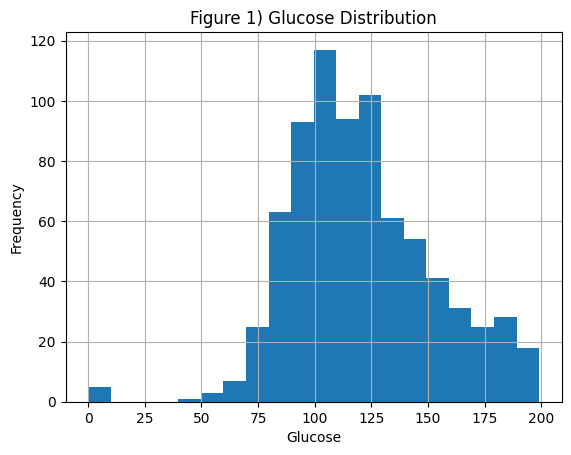

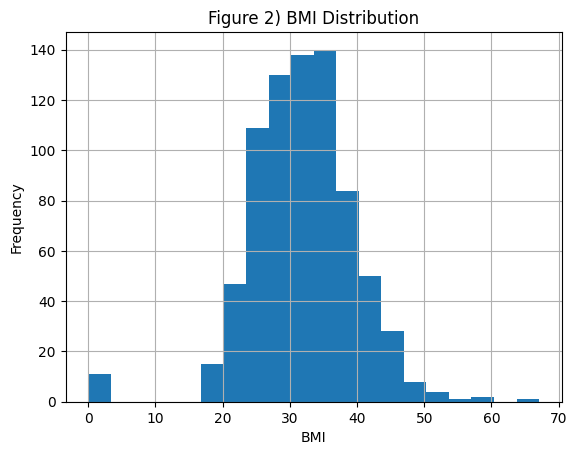

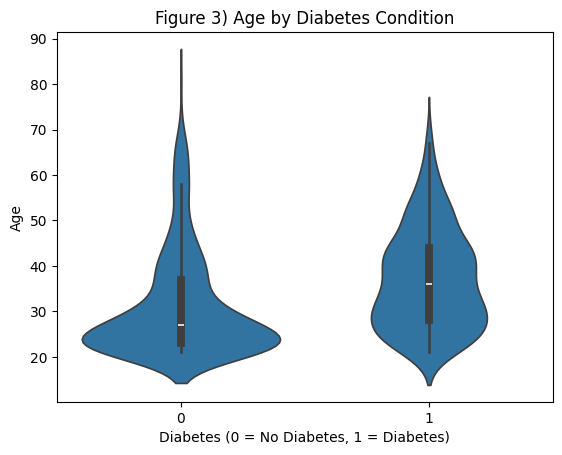

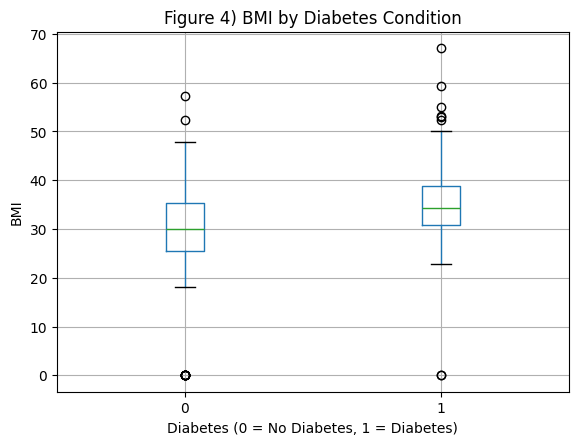

In [61]:
df["Glucose"].hist(bins=20)
plt.title("Figure 1) Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

df["BMI"].hist(bins=20)
plt.title("Figure 2) BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

sns.violinplot(data = df, x = "Outcome", y = "Age")
plt.title("Figure 3) Age by Diabetes Condition")
plt.xlabel("Diabetes (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Age")
plt.show()

df.boxplot(column="BMI", by = "Outcome")
plt.title("Figure 4) BMI by Diabetes Condition")
plt.suptitle("")
plt.xlabel("Diabetes (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("BMI")
plt.show()

**Interpretation**

*Figure 1* shows a glucose distribtion that is a semi-symmetrical bell curve around the average value 120.8, as we discussed in step 7.

*Figure 2* shows a similar bell curve around the average BMI of about 30. BMI is usually directly related to diabetes and we will investigate this.

*Figure 3* is a violin plot that shows the full distribution of the age varible in relation to diabetes. We can see that age clusters at a lower range for non-diabetic people and is spread out for people with diabetes.

*Figure 4* is a simple boxplot showing BMI across diabetic conditions. We can see more outliers and spread in age for diabetic patients. The median BMI looks slightly lower for non-diabetics as well.

# 9. Correlations
A pearson correlation was used to measure the relationship betwee variables in the data. Pearson was appropriate because the analysis is in regard to numerical linear regression relationships. The scale of the relationship rages from -1 to 1. -1 is a very negative correlation and 1 is a very positive correlation.

Text(0.5, 1.0, 'Pearson Correlation Matrix for Diabetes')

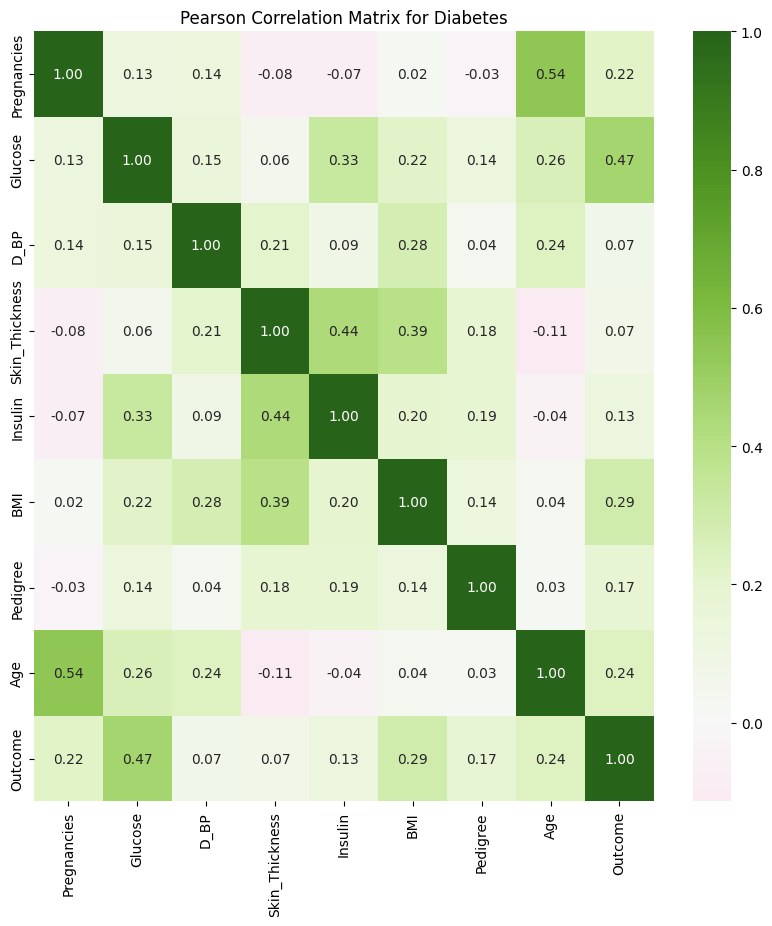

In [62]:
cm = df.corr(method = "pearson")
plt.figure(figsize=(10,10))

sns.heatmap(
    cm,
    annot = True,
    fmt = ".2f",
    cmap = "PiYG",
    center = 0
)
plt.title("Pearson Correlation Matrix for Diabetes")

**Interpretation**

Pregnacy and age have the highest positive correlation while skin thickness and age have the most negative.

When considering correlations to diabetes, we see that glucose and BMI have the strongest positive correlation. There are no strong negative correlations to diabtetes outcome, however, the weakest correlations present are skin thickness and D_BP.

## 10. Inferential Analysis

The following analysis compares glucose values between the two diabetic outcome groups (T-test).

The next test will then compare glucose across age groups, which is helpful for understanding correlations in the variables and possible confounders (ANOVA).

$$
F = \frac{MS_{\text{between}}}{MS_{\text{within}}}
$$

where:

$MS_{\text{between}}$ = variability between the age group means


Run the code as is.

In [63]:
group_0 = df.loc[df["Outcome"] == 0, "Glucose"]
group_1 = df.loc[df["Outcome"] == 1, "Glucose"]

t_stat, p_value = ttest_ind(group_0, group_1)
print("t-statistic:", t_stat)
print("p-value:", p_value)



t-statistic: -14.600060005973894
p-value: 8.935431645289912e-43


**Interpretation**

The p-value is significant, meaning that there is a significant difference of glucose values between diabetic and non-diabetics.

In [64]:
under_thirty = df.loc[df["Age"]<30, "Glucose"]
thirty_to_fifty = df.loc[(df["Age"]>=30) & (df["Age"]<=50), "Glucose"]
over_fifty = df.loc[df["Age"]>50, "Glucose"]

f_stat, p_value = f_oneway(under_thirty, thirty_to_fifty, over_fifty)
print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 28.69642914390531
P-value: 9.60848982588671e-13


**Interpretation**

The ANOVA test p-value is significant, meaning that there is a significant difference in glucose across the three age groups. This indirectly helps our analysis because it helps understand the relationship of diabetes risk factors.

## 11. Data, Statistics, and the Machine Learning Workflow

### Formalizing the Statistical and Machine Learning Problem

In biostatistics and supervised machine learning, we begin with a dataset consisting of observations (in this case patients) and their corresponding target labels (Outcome). We denote the dataset as:

$$
\mathcal{D} = \{(x_i,y_i)\}_{i=1}^{n},
\qquad
x_i \in \mathbb{R}^{p},
\qquad
y_i \in \{0,1\}.
$$

where:

- $\mathcal{D}$ denotes the complete dataset.
- $n$ = 768 is the total number of observations (rows) in the dataset.
- $i$ represents the index of an individual observation, where $i = 1,2,\ldots,768$.
- $x_i$ is the feature vector (predictor variables) corresponding to the $i^{th}$ observation.
- $p$ = 8 is the total number of predictor (feature) variables.
- $\mathbb{R}^{p}$ denotes the $8$-dimensional real-valued feature space.
- $y_i$ = Outcome is the target (response) variable associated with observation $i$.
- $\{0,1\}$ indicates that this is a **binary classification** problem, where:
  - $0$ represents no diabetes.
  - $1$ represents diabetes.

For the diabetes dataset used in this notebook:

$$
x_i =
\begin{bmatrix}
\text{Pregnancies} \\
\text{Glucose} \\
\text{D_BP} \\
\text{SkinThickness} \\
\text{Insulin} \\
\text{BMI} \\
\text{Pedigree} \\
\text{Age}
\end{bmatrix},
\qquad
y_i = \text{Outcome}.
$$

Thus, each observation is represented by a vector of these predictor variables, and the machine learning algorithm learns an estimated prediction function:

$$
\hat{f}: \mathbb{R}^{p} \rightarrow \{0,1\},
$$

where:

- $\hat{f}$ (pronounced *"f-hat"*) denotes the **estimated prediction function** learned from the training data.
- The "hat" indicates that the function is an **estimate** of the unknown relationship between the 8 predictors and diabetes.

The function $\hat{f}(\cdot)$ maps an observation's predictor variables to a predicted class label (0 or 1).

The objective of supervised learning is to estimate the function $\hat{f}(\cdot)$ so that it accurately predicts the the diabetes outcoe for patient data that were **not** used during model training.

## 12. Reproducibility Check
This quick check ensures that even after random sampling the notebook is still producing identical analysis over and over. Run the notebook at least two times and make sure your test below produces the same result.

In [65]:
# A small participant sample used during review
df.sample(8, random_state = 11)

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
210,2,81,60,22,0,27.7,0.290,25,0
340,1,130,70,13,105,25.9,0.472,22,0
649,0,107,60,25,0,26.4,0.133,23,0
477,7,114,76,17,110,23.8,0.466,31,0
432,1,80,74,11,60,30.0,0.527,22,0
60,2,84,0,0,0,0.0,0.304,21,0
341,1,95,74,21,73,25.9,0.673,36,0
278,5,114,74,0,0,24.9,0.744,57,0


In [66]:
# Bootstrap estimate used during exploratory review
bootstrap_mean_bmi = df["BMI"].sample(n=len(df), replace=True, random_state = 11).mean()
print("Bootstrap mean BMI:", bootstrap_mean_bmi)

Bootstrap mean BMI: 31.789322916666666


## Results and Conclusions

**Results**
The results of our analysis have concluded that glucose and BMI are distributed evenly with little skew. The last two plots found differences in distribution and averages over BMI and age across diabetes outcomes. With higher ages and BMIs, and more variability occuring in people who have diabetes. The T-tests and ANOVA found statistically significant (p< 0.001) differences between glucose values across diabetes outcomes, and glucose levels across age groups. When selecting a random sample of patients and using bootstrap mean estimate for BMI, we get 31.8, which is close to the overall average of 31.99

**Next Steps**
More tests must be run to get finite conclusions. Overall, the results show large differences in variable groups in relation to the target outcome of diabetes. We should further investigate age, glucose and BMI and possibly build a machine learning model with these inclusions to predict the outcome better.